# Import Library

In [7]:
import pandas as pd    
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import re  
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from collections import Counter

In [8]:
import sys
import os

current_dir = os.path.abspath('')
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

from script.play_store_scraper import PlayStoreReviews, save_to_csv

# Data Collection

Saya akan mengambil data dari ulasan beberapa aplikasi dari Play Store untuk daerah Britania Raya menggunakan [script](../script/play_store_scraper.py) yang sudah disiapkan. Di sini saya mengambil tema aplikasi **Finance** yang umum digunakan penduduk Britania Raya. Saya sengaja secara spesifik memilih daerah dan tema ini agar mendapatkan ulasan yang benar-benar berbahasa Inggris sesuai kebutuhan.

In [9]:
apps = [
    'co.uk.getmondo',          
    'com.revolut.revolut',              
    'com.starlingbank.android',   
    'com.barclays.android.barclaysmobilebanking',
    'com.grppl.android.shell.CMBlloydsTSB73',
]

total_reviews = 100_000
apps_count = len(apps)  
reviews_per_score_per_app = max(1, (total_reviews // (apps_count * 5)))  

print(f"Target: {total_reviews} ulasan total dari {apps_count} apps")
print(f"Akan mengumpulkan ~{reviews_per_score_per_app} ulasan per score per app")

Target: 100000 ulasan total dari 5 apps
Akan mengumpulkan ~4000 ulasan per score per app


In [10]:
output_dir = "../data/raw"
os.makedirs(output_dir, exist_ok=True)

In [11]:
#Uncomment kode di bawah ini untuk mengambil data ulasan dari Play Store melalui notebook

# all_reviews = []


# for i, app_id in enumerate(apps):
#     print(f"\nMemproses aplikasi {i+1}/{apps_count}: {app_id}")
    
#     scraper = PlayStoreReviews(app_id=app_id, country='gb', verbose=False)
    
#     app_reviews = scraper.fetch(reviews_per_score=reviews_per_score_per_app, balanced=False, sentiment_balanced=True)
    
#     for review in app_reviews:
#         review['app_id'] = app_id
    
#     all_reviews.extend(app_reviews)
    
#     print(f"Mengumpulkan {len(app_reviews)} ulasan untuk {app_id}")
#     print(f"Total: {len(all_reviews)}/{total_reviews}")

In [12]:
# output_file = f"{output_dir}/reviews_finance.csv"

# if not os.path.exists(output_file) :
#     save_to_csv(all_reviews, output_file, overwrite=False)
# else:
#     print(f"File {output_file} sudah ada!")


# Data Wrangling

In [13]:
data_file = "../data/raw/reviews_finance.csv"
df = pd.read_csv(data_file)

df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_id
0,6507d1f0-ee49-488d-9508-6cd3ab58e94a,Charlotte Rajsli,https://play-lh.googleusercontent.com/a-/ALV-U...,Do not use the app for bank transfers! You can...,1,130,5.93.0,2024-10-04 21:47:20,NaN,NaN,5.93.0,co.uk.getmondo
1,f2d264dc-37f7-47fa-b2a6-5b7c7953445b,Euan Seaman,https://play-lh.googleusercontent.com/a/ACg8oc...,"App was initially great, good options for savi...",1,59,6.3.0,2024-12-02 18:26:14,NaN,NaN,6.3.0,co.uk.getmondo
2,a2c9d8bc-eede-4bd3-969b-9abfc3017866,Edd Mowbray,https://play-lh.googleusercontent.com/a/ACg8oc...,"The app doesn't work, I can't progress to open...",1,51,6.9.0,2025-01-21 00:12:29,NaN,NaN,6.9.0,co.uk.getmondo
3,c25b76b5-8022-40a2-8028-2f02ea11167d,Dori Di Bella,https://play-lh.googleusercontent.com/a/ACg8oc...,"Can't open a new account, can't open my old on...",1,34,4.37.0,2024-10-13 13:51:59,NaN,NaN,4.37.0,co.uk.getmondo
4,8fe189fa-387c-4110-bbb0-595a4501dfa5,Richard Hollis,https://play-lh.googleusercontent.com/a/ACg8oc...,"Long time Monzo user. Had been avoiding this, ...",1,242,5.53.0,2023-12-14 16:23:40,NaN,NaN,5.53.0,co.uk.getmondo


In [14]:
def is_english(text):
    if not isinstance(text, str) or text.strip() == '':
        return False
    try:
        return detect(text) == 'en'
    except LangDetectException:
        return False

print(f"Ukuran dataset: {len(df)}")

df = df[df['content'].apply(lambda x: is_english(x) if isinstance(x, str) else False)]

print(f"Ukuran dataset setelah filter bahasa: {len(df)}")

Ukuran dataset: 84833
Ukuran dataset setelah filter bahasa: 79426


In [15]:
print("\nMissing values:")
missing_values = df.isnull().sum()
print(missing_values)

print("\nDuplikat:")
duplicate_rows = df.duplicated().sum()
print(f"Total duplikat: {duplicate_rows}")


Missing values:
reviewId                    0
userName                    0
userImage                   0
content                     0
score                       0
thumbsUpCount               0
reviewCreatedVersion     7085
at                          0
replyContent            50162
repliedAt               50162
appVersion               7085
app_id                      0
dtype: int64

Duplikat:
Total duplikat: 17520


In [16]:
if duplicate_rows > 0:
    df = df.drop_duplicates()
    print(f"Shape baru: {df.shape}")

Shape baru: (61906, 12)


In [17]:
df.describe()

,score,thumbsUpCount
count,61906.000000,61906.000000
mean,3.056941,3.357009
std,1.440875,16.391028
min,1.000000,0.000000
25%,2.000000,0.000000
50%,3.000000,0.000000
75%,4.000000,1.000000
max,5.000000,842.000000


In [18]:
def clean_text(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower()  
    text = re.sub(r'\S+@\S+', '', text) 
    text = re.sub(r'[^\w\s]', '', text) 
    text = text.strip()  
    
    return text

if 'content' in df.columns:
    df['cleaned_content'] = df['content'].apply(lambda x: clean_text(x) if isinstance(x, str) else '')


In [19]:
df = df.dropna(subset=['content', 'score'])

df = df[df['cleaned_content'] != '']

In [20]:
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_id,cleaned_content
0,6507d1f0-ee49-488d-9508-6cd3ab58e94a,Charlotte Rajsli,https://play-lh.googleusercontent.com/a-/ALV-U...,Do not use the app for bank transfers! You can...,1,130,5.93.0,2024-10-04 21:47:20,NaN,NaN,5.93.0,co.uk.getmondo,do not use the app for bank transfers you can ...
1,f2d264dc-37f7-47fa-b2a6-5b7c7953445b,Euan Seaman,https://play-lh.googleusercontent.com/a/ACg8oc...,"App was initially great, good options for savi...",1,59,6.3.0,2024-12-02 18:26:14,NaN,NaN,6.3.0,co.uk.getmondo,app was initially great good options for savin...
2,a2c9d8bc-eede-4bd3-969b-9abfc3017866,Edd Mowbray,https://play-lh.googleusercontent.com/a/ACg8oc...,"The app doesn't work, I can't progress to open...",1,51,6.9.0,2025-01-21 00:12:29,NaN,NaN,6.9.0,co.uk.getmondo,the app doesnt work i cant progress to opening...
3,c25b76b5-8022-40a2-8028-2f02ea11167d,Dori Di Bella,https://play-lh.googleusercontent.com/a/ACg8oc...,"Can't open a new account, can't open my old on...",1,34,4.37.0,2024-10-13 13:51:59,NaN,NaN,4.37.0,co.uk.getmondo,cant open a new account cant open my old one n...
4,8fe189fa-387c-4110-bbb0-595a4501dfa5,Richard Hollis,https://play-lh.googleusercontent.com/a/ACg8oc...,"Long time Monzo user. Had been avoiding this, ...",1,242,5.53.0,2023-12-14 16:23:40,NaN,NaN,5.53.0,co.uk.getmondo,long time monzo user had been avoiding this bu...


In [21]:
cleaned_data_file = "../data/interim/cleaned_reviews_finance.csv"
df.to_csv(cleaned_data_file, index=False)
print(f"\nData yang bersih disimpan di {cleaned_data_file}")


Data yang bersih disimpan di ../data/interim/cleaned_reviews_finance.csv


**Key Takepoint(s)**:
- Untuk memastikan, saya menyaring kembali ulasan yang bukan berbahasa Inggris
- Saya lebih memilih untuk tidak mengimplementasikan stopwords atau semacamnya dan membersihkan saja teks secara biasa untuk mencegah hilangnya makna dari teks
- Terlihat bahwa data setelah dibersihkan berjumlah lebih dari 60 ribu
 
**✅ Submission Progress Tracker:**
- [x] Dataset ≥ 10.000 sampel 
- [ ] Dataset  ≥ 3 kelas
- [ ] Menggunakan algoritma deep learning
- [ ] Akurasi training ≥ 92%
- [ ] Akurasi testing ≥ 92% **atau** min. 3 percobaan testing ≥ 85%
- [ ] Min. 3 skema pelatihan berbeda dengan min. 2 variasi (algoritma / fitur / split / label)
  - [ ] Skema 1: (Algoritma, Fitur, Split, Akurasi)
  - [ ] Skema 2: (Algoritma, Fitur, Split, Akurasi)
  - [ ] Skema 3: (Algoritma, Fitur, Split, Akurasi)
- [ ] Cell inference untuk testing dengan output berupa kelas kategorikal


# Exploratory Data Analysis & Labeling
Analyze review scores distribution, review length, and other metrics. Create visualizations showing rating patterns across different apps.

In [22]:
score_distribution = df['score'].value_counts()
print(score_distribution)

score
3    14393
5    13662
1    13408
4    11730
2     8713
Name: count, dtype: int64


2025-04-12 17:37:15,367 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/tmp/ipykernel_372455/4150043336.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='score', palette='viridis')
2025-04-12 17:37:15,392 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


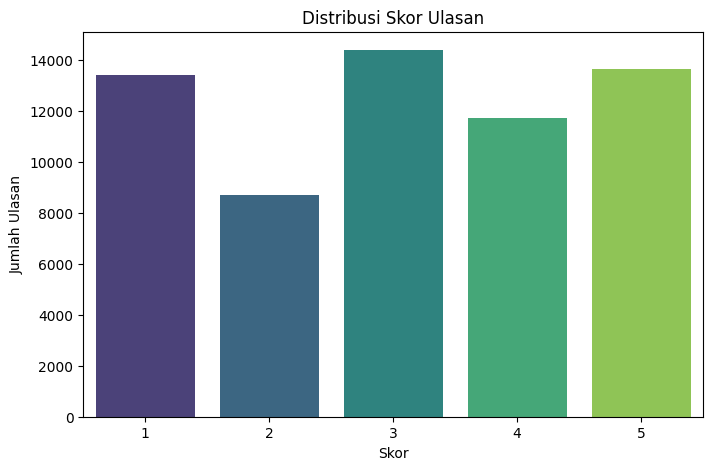

In [23]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='score', palette='viridis')
plt.title('Distribusi Skor Ulasan')
plt.xlabel('Skor')
plt.ylabel('Jumlah Ulasan')
plt.show()

In [24]:
def label_sentiment(score):
    if score in [1, 2]:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    elif score in [4, 5]:
        return 'Positive'
    else:
        return 'Unknown'

df['label'] = df['score'].apply(label_sentiment)

In [25]:
df[['score', 'label']].head()

,score,label
0,1,Negative
1,1,Negative
2,1,Negative
3,1,Negative
4,1,Negative


In [26]:
df[['score', 'label']].tail()

,score,label
84822,5,Positive
84825,5,Positive
84828,5,Positive
84829,5,Positive
84831,5,Positive


In [27]:
def analyze_sentiment_with_vader(text):
    if not isinstance(text, str) or text.strip() == '':
        return 'Neutral' 
        
    analyzer = SentimentIntensityAnalyzer()
    
    scores = analyzer.polarity_scores(text)
    
    if scores['compound'] >= 0.05:
        return 'Positive'
    elif scores['compound'] <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

def create_vader_labeled_dataset(input_file, output_file):

    df = pd.read_csv(input_file)
    
    print(f"Analyzing sentiment for {len(df)} reviews using VADER...")
    
    df['vader_label'] = df['text'].apply(analyze_sentiment_with_vader)
    
    df.to_csv(output_file, index=False)
    print(f"VADER sentiment labeled data saved to {output_file}")
    
    return df

In [28]:
df.rename(columns={'cleaned_content': 'text'}, inplace=True)

In [29]:
df['vader_label'] = df['text'].apply(analyze_sentiment_with_vader)

In [30]:
df['label'].value_counts()

label
Positive    25392
Negative    22121
Neutral     14393
Name: count, dtype: int64

In [31]:
df['vader_label'].value_counts()

vader_label
Positive    35921
Negative    19350
Neutral      6635
Name: count, dtype: int64

In [32]:
sentiment_distribution = df['score'].value_counts()
print(sentiment_distribution)

score
3    14393
5    13662
1    13408
4    11730
2     8713
Name: count, dtype: int64


/tmp/ipykernel_372455/2860644654.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='pastel', order=['Negative', 'Neutral', 'Positive'])


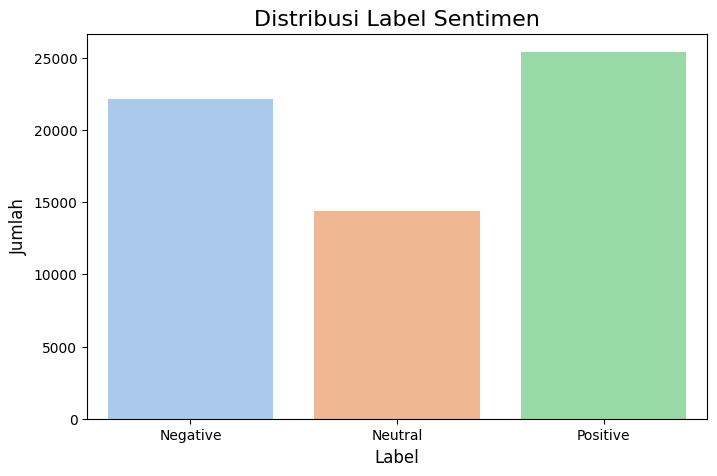

In [33]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', palette='pastel', order=['Negative', 'Neutral', 'Positive'])
plt.title('Distribusi Label Sentimen', fontsize=16)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

/tmp/ipykernel_372455/141096019.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='vader_label', palette='viridis', order=['Negative', 'Neutral', 'Positive'])


Text(0, 0.5, 'Count')

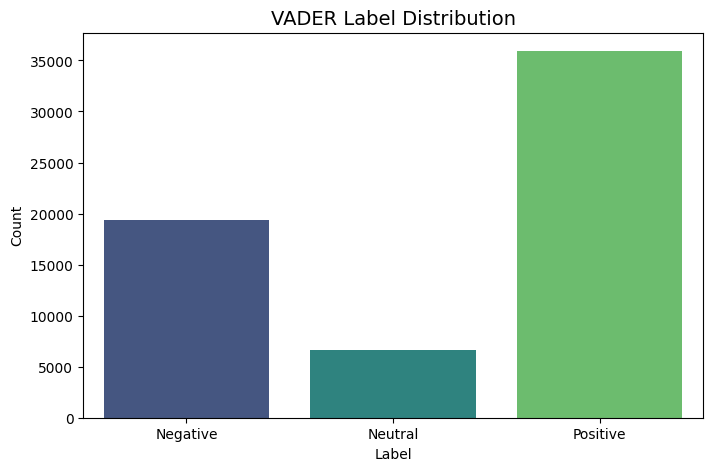

In [34]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='vader_label', palette='viridis', order=['Negative', 'Neutral', 'Positive'])
plt.title('VADER Label Distribution', fontsize=14)
plt.xlabel('Label')
plt.ylabel('Count')

In [35]:
vader_labeled_data = df[['text', 'vader_label']].rename(columns={'vader_label': 'label'})

In [36]:
# vader_data_file = "../data/processed/vader_labeled_reviews_finance.csv"
# vader_labeled_data.to_csv(vader_data_file, index=False)

In [37]:
vader_positive = vader_labeled_data[vader_labeled_data['label'] == 'Positive'].sample(3, random_state=42)
vader_neutral = vader_labeled_data[vader_labeled_data['label'] == 'Neutral'].sample(3, random_state=42)
vader_negative = vader_labeled_data[vader_labeled_data['label'] == 'Negative'].sample(3, random_state=42)
vader_test_samples = pd.concat([vader_positive, vader_neutral, vader_negative])

In [38]:
vader_test_file = "../data/processed/vader_test_samples_finance.csv"
vader_test_samples.to_csv(vader_test_file, index=False)

In [39]:
vader_labeled_data['id'] = vader_labeled_data['text'] + vader_labeled_data['label']
vader_test_samples['id'] = vader_test_samples['text'] + vader_test_samples['label']

In [40]:
vader_test_ids = set(vader_test_samples['id'])

In [41]:
vader_filtered_data = vader_labeled_data[~vader_labeled_data['id'].isin(vader_test_ids)]
vader_filtered_data = vader_filtered_data.drop('id', axis=1)

In [42]:
vader_filtered_file = "../data/processed/vader_reviews_finance.csv"
vader_filtered_data.to_csv(vader_filtered_file, index=False)

In [43]:
print(f"Full: {len(vader_labeled_data)}")
print(f"Sampel: {len(vader_test_samples)}")
print(f"Filtered: {len(vader_filtered_data)}")

Full: 61906
Sampel: 9
Filtered: 61897


In [44]:
labeled_data = df[['text', 'label']]
positive_samples = labeled_data[labeled_data['label'] == 'Positive'].sample(3, random_state=42)
neutral_samples = labeled_data[labeled_data['label'] == 'Neutral'].sample(3, random_state=42)
negative_samples = labeled_data[labeled_data['label'] == 'Negative'].sample(3, random_state=42)
test_samples = pd.concat([positive_samples, neutral_samples, negative_samples])

test_samples_file = "../data/processed/test_samples_finance.csv"
test_samples.to_csv(test_samples_file, index=False)
print(f"\nSampel data pengujian (9 reviews) disimpan ke {test_samples_file}")
test_samples


Sampel data pengujian (9 reviews) disimpan ke ../data/processed/test_samples_finance.csv

,text,label
30388,the facilties you offer and the site design is...,Positive
40447,easy to use for now and i would like try it in...,Positive
80997,very easy to use,Positive
55893,quick and easy,Neutral
55183,could be bug free,Neutral
21778,no easy way to contact customer service,Neutral
3333,does nothing and cannot login,Negative
66821,to much advertising stuff that you dont need i...,Negative
48338,last review a few years ago was it was fast an...,Negative


In [45]:
labeled_data['id'] = labeled_data['text'] + labeled_data['label']
test_samples['id'] = test_samples['text'] + test_samples['label']

test_sample_ids = set(test_samples['id'])

filtered_data = labeled_data[~labeled_data['id'].isin(test_sample_ids)]

filtered_data = filtered_data.drop('id', axis=1)

filtered_data_file = "../data/processed/data_reviews_finance.csv"
filtered_data[['text', 'label']].to_csv(filtered_data_file, index=False)

print(f"\nDataset filterded (tanpa sampel pengujian) disimpan ke {filtered_data_file}")

/tmp/ipykernel_372455/208618430.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labeled_data['id'] = labeled_data['text'] + labeled_data['label']



Dataset filterded (tanpa sampel pengujian) disimpan ke ../data/processed/data_reviews_finance.csv


In [46]:
print(f"Ukuran dataset asli: {len(labeled_data)}")
print(f"Ukuran sampel pengujian: {len(test_samples)}")
print(f"Ukuran dataset filtered: {len(filtered_data)}")

Ukuran dataset asli: 61906
Ukuran sampel pengujian: 9
Ukuran dataset filtered: 61854


In [47]:
def generate_wordclouds(dataframe, text_column, label_column, title_prefix):
    
    sentiment_categories = ['Negative', 'Neutral', 'Positive']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'{title_prefix} Wordclouds by Sentiment', fontsize=16)
    
    for i, sentiment in enumerate(sentiment_categories):
        sentiment_texts = ' '.join(dataframe[dataframe[label_column] == sentiment][text_column])
        
        if sentiment_texts.strip() == '':
            axes[i].text(0.5, 0.5, f"No text data for {sentiment}", 
                        horizontalalignment='center', verticalalignment='center')
            axes[i].set_title(sentiment)
            axes[i].axis('off')
            continue
        
        wordcloud = WordCloud(
            width=400, 
            height=400, 
            background_color='white',
            max_words=100,
            contour_width=3,
            contour_color='steelblue'
        ).generate(sentiment_texts)
        
        axes[i].imshow(wordcloud, interpolation='bilinear')
        axes[i].set_title(sentiment)
        axes[i].axis('off')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()



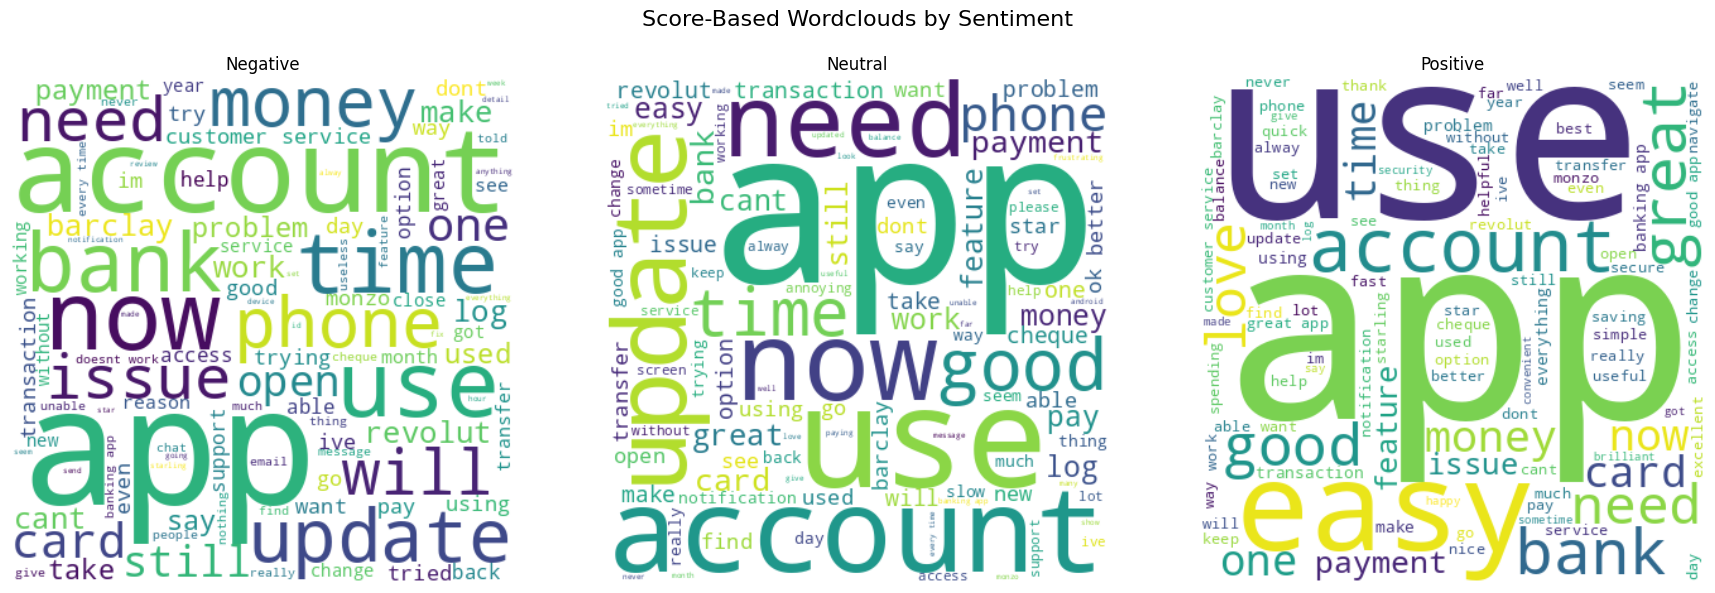

In [48]:
generate_wordclouds(df, 'text', 'label', 'Score-Based')

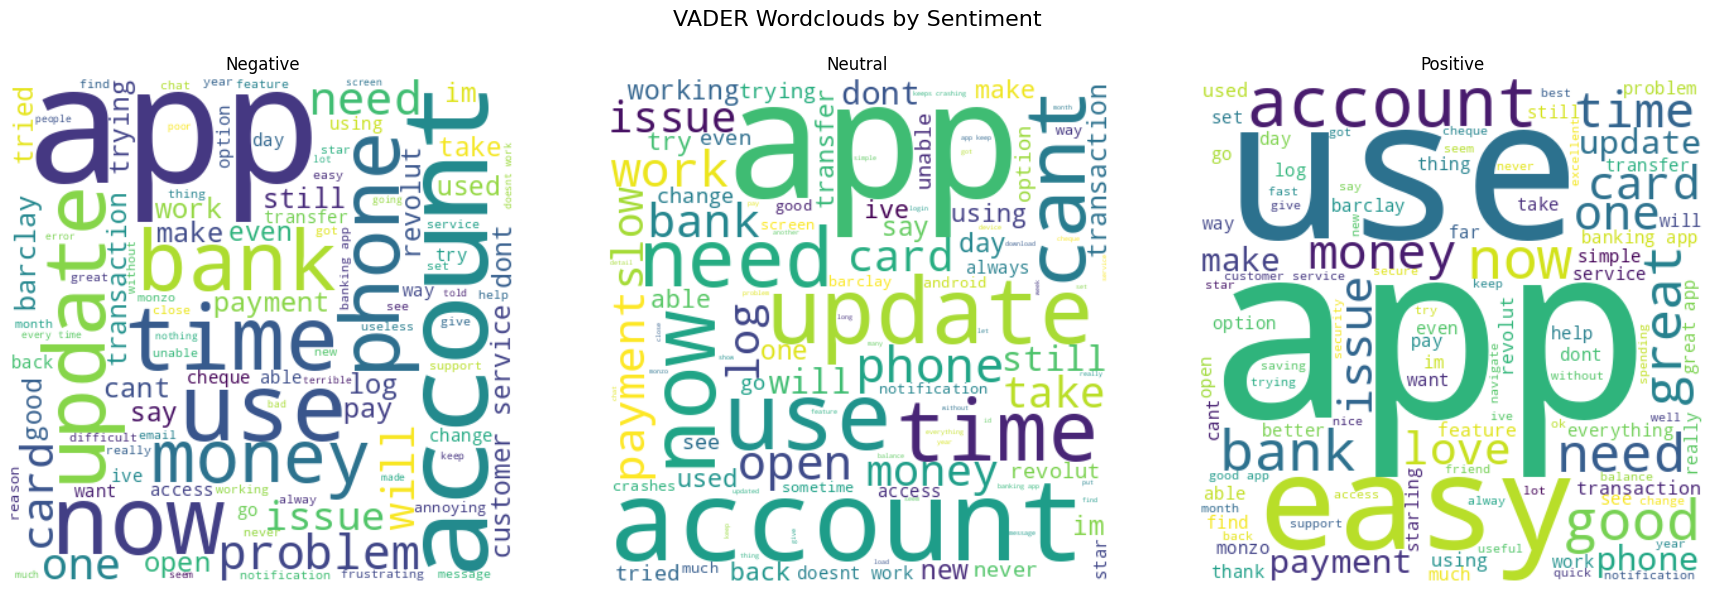

In [49]:
generate_wordclouds(df, 'text', 'vader_label', 'VADER')

**Key Takepoint(s)**:
- Saya menyiapkan dua dataset di sini untuk jaga-jaga, yakni dataset yang dilabel melalui score dan melalui vader. Keduanya memiliki 3 label Positif, Negatif, dan Netral.
- Terlihat dari hasil EDA bahwa dataset yang dilabel menggunakan score mengalami sedikit class imbalance, namun kualitas labelnya kemungkinan kurang tepat, seperti ulasan netral yang harusnya terdapat di positif. Dataset yang dilabel menggunakan VADER memiliki class imbalance, namun kualitas labelnya seharusnya akan lebih tepat.
- Saya hanya akan menampilkan modelling untuk dataset yang menghasilkan performa terbaik, modelling ini perlu saya pisah di [notebook yang berbeda](./modelling.ipynb) karna kemungkinan akan saya lakukan di environtment berbeda jika komputer saya tidak memadai.
 
**✅ Submission Progress Tracker:**
- [x] Dataset ≥ 10.000 sampel 
- [x] Dataset  ≥ 3 kelas
- [ ] Menggunakan algoritma deep learning
- [ ] Akurasi training ≥ 92%
- [ ] Akurasi testing ≥ 92% **atau** min. 3 percobaan testing ≥ 85%
- [ ] Min. 3 skema pelatihan berbeda dengan min. 2 variasi (algoritma / fitur / split / label)
  - [ ] Skema 1: (Algoritma, Fitur, Split, Akurasi)
  - [ ] Skema 2: (Algoritma, Fitur, Split, Akurasi)
  - [ ] Skema 3: (Algoritma, Fitur, Split, Akurasi)
- [ ] Cell inference untuk testing dengan output berupa kelas kategorikal
